In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Datasets

In [3]:
dim_date = pd.read_csv("C:/Users/hp/Downloads/EV launch/RPC12_Input_For_Participants/datasets/dim_date.csv")
dim_date.head()

,date,fiscal_year,quarter
0,01-Apr-21,2022,Q1
1,01-May-21,2022,Q1
2,01-Jun-21,2022,Q1
3,01-Jul-21,2022,Q2
4,01-Aug-21,2022,Q2


In [4]:
by_makers = pd.read_csv("C:/Users/hp/Downloads/EV launch/RPC12_Input_For_Participants/datasets/electric_vehicle_sales_by_makers.csv")
by_makers.head()

,date,vehicle_category,maker,electric_vehicles_sold
0,01-Apr-21,2-Wheelers,OLA ELECTRIC,0
1,01-Apr-22,2-Wheelers,OKAYA EV,0
2,01-May-21,2-Wheelers,OLA ELECTRIC,0
3,01-Jun-21,2-Wheelers,OLA ELECTRIC,0
4,01-Jul-21,2-Wheelers,OLA ELECTRIC,0


In [5]:
by_state = pd.read_csv("C:/Users/hp/Downloads/EV launch/RPC12_Input_For_Participants/datasets/electric_vehicle_sales_by_state.csv")
by_state.head()

,date,state,vehicle_category,electric_vehicles_sold,total_vehicles_sold
0,01-Apr-21,Sikkim,2-Wheelers,0,398
1,01-Apr-21,Sikkim,4-Wheelers,0,361
2,01-May-21,Sikkim,2-Wheelers,0,113
3,01-May-21,Sikkim,4-Wheelers,0,98
4,01-Jun-21,Sikkim,2-Wheelers,0,229


### Analysis (dim_date)

In [6]:
dim_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         36 non-null     object
 1   fiscal_year  36 non-null     int64 
 2   quarter      36 non-null     object
dtypes: int64(1), object(2)
memory usage: 996.0+ bytes


In [9]:
dim_date['date'] = pd.to_datetime(dim_date['date'], format='%Y-%m=%d')

In [10]:
dim_date['fiscal_year'] = dim_date['fiscal_year'].astype(int)
dim_date.head()

,date,fiscal_year,quarter
0,2021-04-01,2022,Q1
1,2021-05-01,2022,Q1
2,2021-06-01,2022,Q1
3,2021-07-01,2022,Q2
4,2021-08-01,2022,Q2


In [11]:
#dim_date['quarter'].value_counts().reset_index()

### Analysis (by_makers)

In [12]:
by_makers.shape

(816, 4)

In [13]:
by_makers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    816 non-null    object
 1   vehicle_category        816 non-null    object
 2   maker                   816 non-null    object
 3   electric_vehicles_sold  816 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 25.6+ KB


In [16]:
by_makers['date'] = pd.to_datetime(by_makers['date'], format='%Y-%m-%d')
by_makers.head()

,date,vehicle_category,maker,electric_vehicles_sold
0,2021-04-01,2-Wheelers,OLA ELECTRIC,0
1,2022-04-01,2-Wheelers,OKAYA EV,0
2,2021-05-01,2-Wheelers,OLA ELECTRIC,0
3,2021-06-01,2-Wheelers,OLA ELECTRIC,0
4,2021-07-01,2-Wheelers,OLA ELECTRIC,0


In [17]:
#by_makers['maker'].value_counts()

In [18]:
by_makers.rename(columns={'electric_vehicles_sold':'ev_sold'}, inplace=True)

In [19]:
#separate 2 wheelers and 4 wheelers
two = by_makers.loc[by_makers['vehicle_category']=='2-Wheelers']
four = by_makers.loc[by_makers['vehicle_category']=='4-Wheelers']

In [20]:
total_2m = two['ev_sold'].sum()
print('Total 2 wheelers sold:', total_2m)
total_4m = four['ev_sold'].sum()
print('Total 4 wheelers sold:', total_4m)

Total 2 wheelers sold: 1913168
Total 4 wheelers sold: 152943


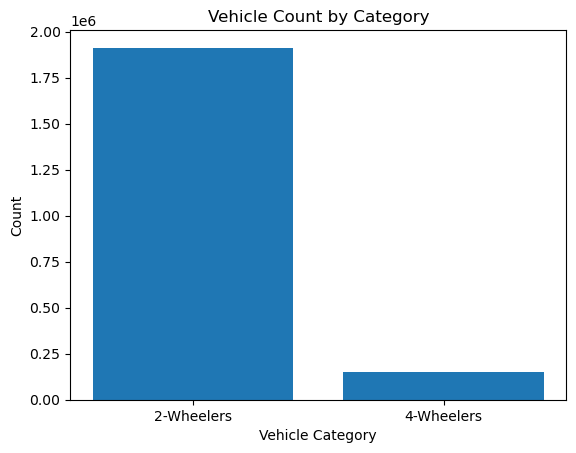

In [21]:
##
categories = ['2-Wheelers','4-Wheelers']
vals = [total_2m, total_4m]
plt.bar(categories, vals)
plt.title('Vehicle Count by Category')
plt.xlabel('Vehicle Category')
plt.ylabel('Count')
plt.show()

### Analysis (by_state)

In [22]:
by_state.shape

(2445, 5)

In [23]:
by_state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2445 entries, 0 to 2444
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    2445 non-null   object
 1   state                   2445 non-null   object
 2   vehicle_category        2445 non-null   object
 3   electric_vehicles_sold  2445 non-null   int64 
 4   total_vehicles_sold     2445 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 95.6+ KB


In [26]:
by_state['date'] = pd.to_datetime(by_state['date'], format='%Y-%m-%d')

In [27]:
#2 rows with A&N and A&N islands
by_state['state']= by_state['state'].replace('Andaman & Nicobar Island', 'Andaman & Nicobar')

In [28]:
#by_state['state'].value_counts()

In [29]:
by_state.rename(columns={'electric_vehicles_sold':'ev_sold'}, inplace=True)

In [30]:
total_ev_per_state = by_state.groupby('state')['ev_sold'].sum()
total_ev_per_state.sort_values(ascending=False).reset_index().head(10)

,state,ev_sold
0,Maharashtra,396045
1,Karnataka,312995
2,Tamil Nadu,200062
3,Gujarat,181389
4,Rajasthan,150366
5,Kerala,137060
6,Delhi,107312
7,Uttar Pradesh,95203
8,Madhya Pradesh,78979
9,Odisha,78267


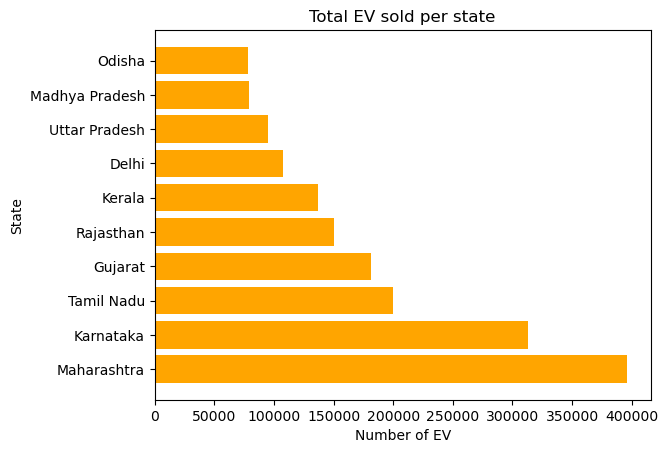

In [31]:
#top states for EV sales
total_ev = total_ev_per_state.sort_values(ascending=False).head(10)
#plt.figure(figsize=(8,8))
plt.barh(total_ev.index, total_ev.values, color='orange')
plt.title('Total EV sold per state')
plt.xlabel('Number of EV')
plt.ylabel('State')
plt.show()

In [32]:
total_vehicle_per_state = by_state.groupby('state')['total_vehicles_sold'].sum()
#total_vehicle_per_state.sort_values(ascending=False).reset_index().head(10)

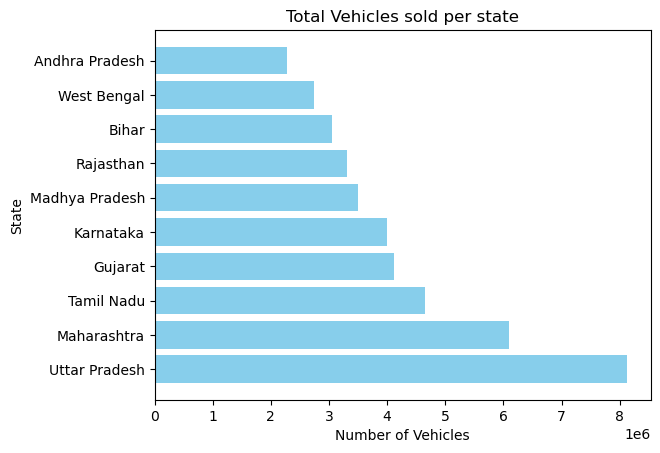

In [33]:
#top cities for total vehicles sold
total_vehicle = total_vehicle_per_state.sort_values(ascending=False).head(10)
#plt.figure(figsize=(8,8))
plt.barh(total_vehicle.index, total_vehicle.values, color='skyblue')
plt.title('Total Vehicles sold per state')
plt.xlabel('Number of Vehicles')
plt.ylabel('State')
plt.show()

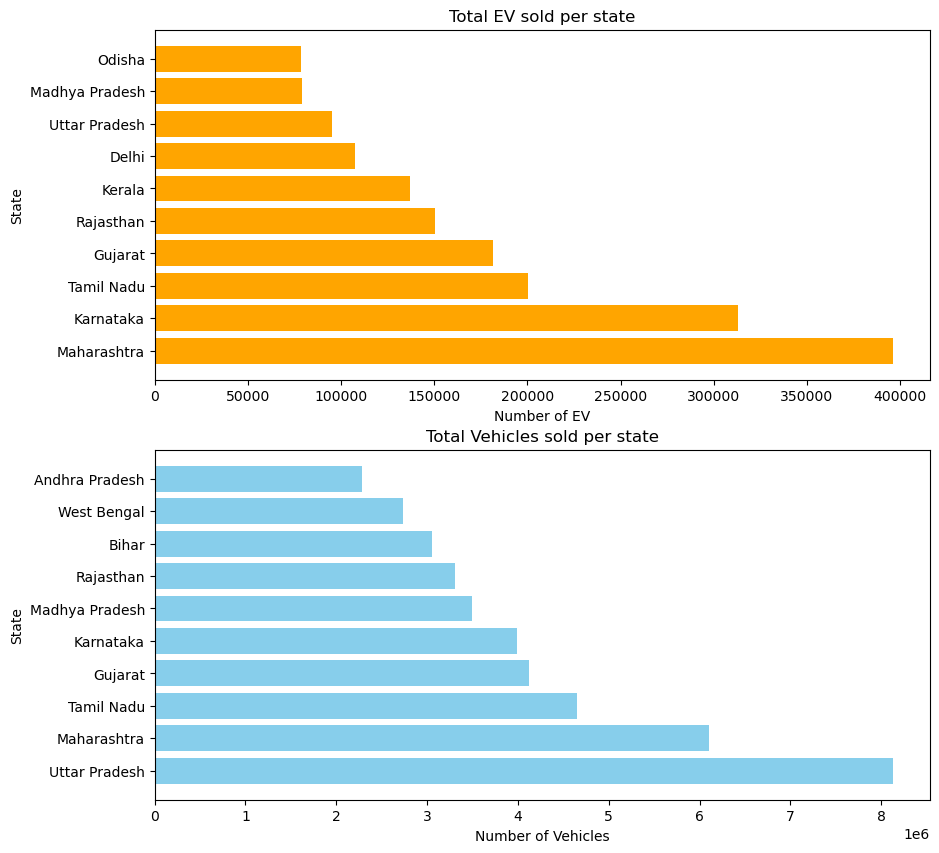

In [34]:
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
plt.barh(total_ev.index, total_ev.values, color='orange')
plt.title('Total EV sold per state')
plt.xlabel('Number of EV')
plt.ylabel('State')

plt.subplot(2,1,2)
plt.barh(total_vehicle.index, total_vehicle.values, color='skyblue')
plt.title('Total Vehicles sold per state')
plt.xlabel('Number of Vehicles')
plt.ylabel('State')

plt.show()

In [36]:
comp = pd.merge(total_vehicle_per_state,total_ev_per_state, on='state')
#comp.sort_values(by='total_vehicles_sold', ascending=False).head(10)

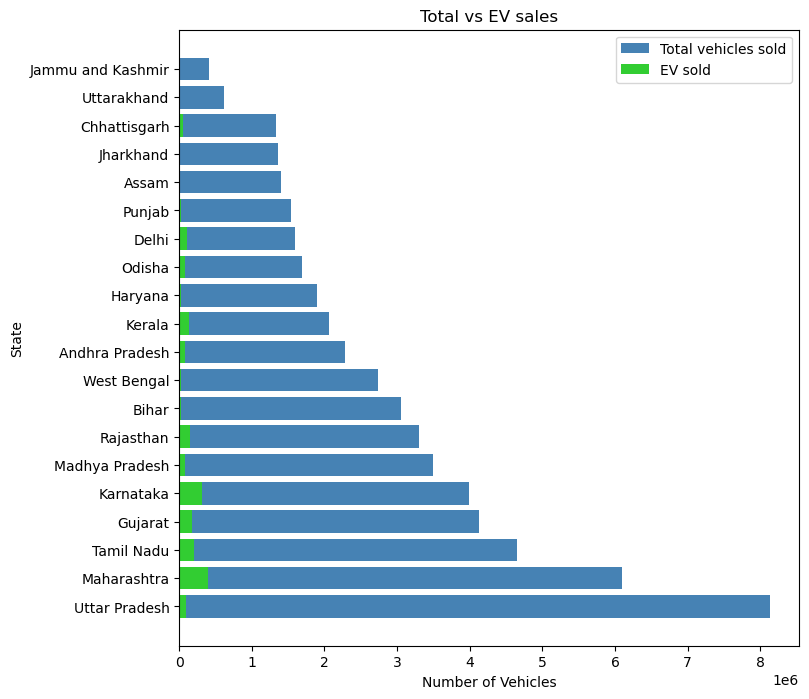

In [37]:
#EV sold in comparison with total vehicles sold
comp_new = comp.sort_values(by='total_vehicles_sold', ascending=False).head(20)
plt.figure(figsize=(8,8))
plt.barh(comp_new.index, comp_new['total_vehicles_sold'], label='Total vehicles sold', color='steelblue')
plt.barh(comp_new.index, comp_new['ev_sold'], label='EV sold', color='limegreen')
plt.title('Total vs EV sales')
plt.ylabel('State')
plt.xlabel('Number of Vehicles')
plt.legend()
plt.show()

In [38]:
ev_of_total = by_state['ev_sold'].sum()/by_state['total_vehicles_sold'].sum()*100
print('EV share (%) in total vehicle sales:',ev_of_total)

EV share (%) in total vehicle sales: 3.6108037413047396


In [39]:
# % of total vehicles that are EV
ev_perc = (comp['ev_sold']/comp['total_vehicles_sold']*100).rename('ev_of_total_percentage')
ev_perc.sort_values(ascending=False).reset_index().head(10)

,state,ev_of_total_percentage
0,Goa,9.843477
1,Karnataka,7.835984
2,Delhi,6.755828
3,Kerala,6.638326
4,Maharashtra,6.491020
5,Odisha,4.634491
6,Rajasthan,4.546088
7,Gujarat,4.396722
8,Tamil Nadu,4.300223
9,Chandigarh,4.041247


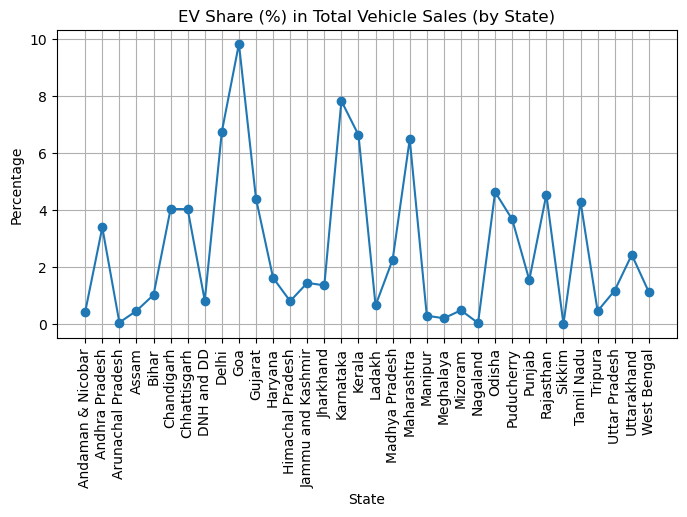

In [40]:
plt.figure(figsize=(8,4))
plt.plot(ev_perc, marker='o')
plt.xticks(rotation=90)
plt.title('EV Share (%) in Total Vehicle Sales (by State)')
plt.xlabel('State')
plt.ylabel('Percentage')
plt.grid()
plt.show()

In [41]:
#split into 2-wheelers and 4-wheelers
two2 = by_state.loc[by_state['vehicle_category']=='2-Wheelers']
two2.shape

(1223, 5)

In [42]:
four2 = by_state.loc[by_state['vehicle_category']=='4-Wheelers']
four2.shape

(1222, 5)

In [43]:
#two wheelers
two_ev_by_state = two2.groupby('state')['ev_sold'].sum()
two_total_by_state = two2.groupby('state')['total_vehicles_sold'].sum()

#four wheelers
four_ev_by_state = four2.groupby('state')['ev_sold'].sum()
four_total_by_state = four2.groupby('state')['total_vehicles_sold'].sum()

In [45]:
vc = {
    #'state' : by_state['state'].unique(),
    'total vehicles sold' : total_vehicle_per_state,
    'total 2 wheelers sold' : two_total_by_state,
    'electric 2 wheelers sold' : two_ev_by_state,
    'total 4 wheelers sold' : four_total_by_state,
    'electric 4 wheelers sold' : four_ev_by_state
}
comp_by_vehicle_category = pd.DataFrame(vc)
#comp_by_vehicle_category
comp_by_vehicle_category.sort_values(by='total vehicles sold', ascending=False).head(10)

,total vehicles sold,total 2 wheelers sold,electric 2 wheelers sold,total 4 wheelers sold,electric 4 wheelers sold
state,,,,,
Uttar Pradesh,8127084,7028450,89165,1098634,6038
Maharashtra,6101429,4821434,363765,1279995,32280
Tamil Nadu,4652363,3945865,188855,706498,11207
Gujarat,4125551,3181823,169557,943728,11832
Karnataka,3994329,3203736,292329,790593,20666
Madhya Pradesh,3498698,3041912,76362,456786,2617
Rajasthan,3307591,2769367,142425,538224,7941
Bihar,3048373,2836853,30020,211520,999
West Bengal,2736176,2430614,25863,305562,4697


In [46]:
#% of 2 and 4 wheelers sold that are electric
comp = comp_by_vehicle_category.copy()
comp['2w_ev'] = (comp['electric 2 wheelers sold'] / comp['total 2 wheelers sold']) * 100
comp['4w_ev'] = (comp['electric 4 wheelers sold'] / comp['total 4 wheelers sold']) * 100

### 2D Analysis

In [47]:
makers_date = pd.merge(by_makers, dim_date, on='date')
makers_date

,date,vehicle_category,maker,ev_sold,fiscal_year,quarter
0,2021-04-01,2-Wheelers,OLA ELECTRIC,0,2022,Q1
1,2022-04-01,2-Wheelers,OKAYA EV,0,2023,Q1
2,2021-05-01,2-Wheelers,OLA ELECTRIC,0,2022,Q1
3,2021-06-01,2-Wheelers,OLA ELECTRIC,0,2022,Q1
4,2021-07-01,2-Wheelers,OLA ELECTRIC,0,2022,Q2
...,...,...,...,...,...,...
811,2024-03-01,2-Wheelers,BGAUSS,3070,2024,Q4
812,2024-03-01,2-Wheelers,BATTRE ELECTRIC,625,2024,Q4
813,2024-03-01,2-Wheelers,KINETIC GREEN,3915,2024,Q4
814,2024-03-01,2-Wheelers,REVOLT,585,2024,Q4


In [48]:
#EV sales growth per year by vehicle category
ev_per_fy = makers_date.groupby(['vehicle_category','fiscal_year'])['ev_sold'].sum()
ev_per_fy.reset_index()

,vehicle_category,fiscal_year,ev_sold
0,2-Wheelers,2022,252573
1,2-Wheelers,2023,727903
2,2-Wheelers,2024,932692
3,4-Wheelers,2022,18577
4,4-Wheelers,2023,47465
5,4-Wheelers,2024,86901


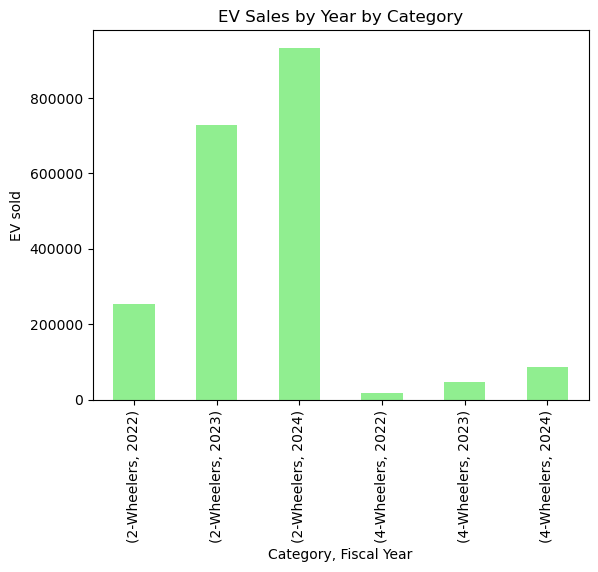

In [49]:
ev_per_fy.plot(kind='bar', color='lightgreen')
plt.title('EV Sales by Year by Category')
plt.xlabel('Category, Fiscal Year')
plt.ylabel('EV sold')
plt.show()

In [50]:
ev_df = pd.DataFrame(ev_per_fy)

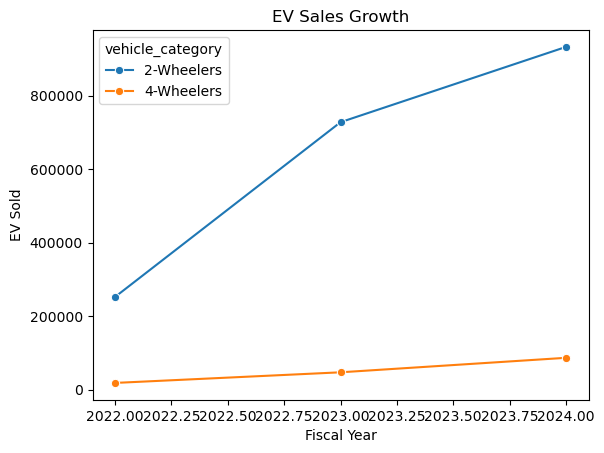

In [51]:
sns.lineplot(data=ev_df, x='fiscal_year', y='ev_sold', hue='vehicle_category',marker="o")
plt.title("EV Sales Growth")
plt.xlabel("Fiscal Year")
plt.ylabel("EV Sold")
plt.show()

In [52]:
#EV sales by category by quarter (to analyze which quarter of the year has more sales)
ev_quarter = makers_date.groupby(['vehicle_category','quarter'])['ev_sold'].sum()
ev_quarter.reset_index()

,vehicle_category,quarter,ev_sold
0,2-Wheelers,Q1,369682
1,2-Wheelers,Q2,381279
2,2-Wheelers,Q3,531999
3,2-Wheelers,Q4,630208
4,4-Wheelers,Q1,31553
5,4-Wheelers,Q2,34080
6,4-Wheelers,Q3,38783
7,4-Wheelers,Q4,48527


In [53]:
quarter_df = pd.DataFrame(ev_quarter)

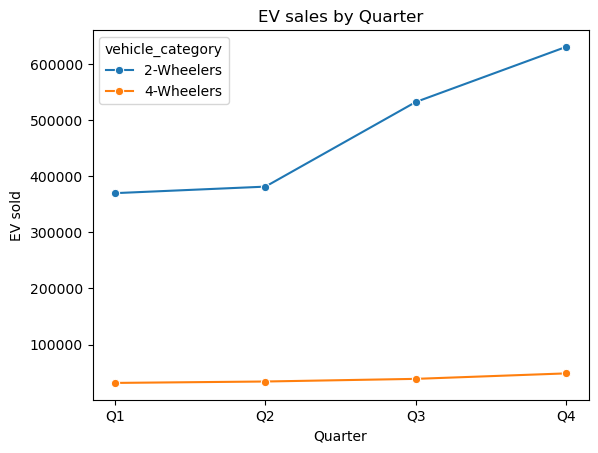

In [54]:
sns.lineplot(data=quarter_df, x='quarter',y='ev_sold',hue='vehicle_category',marker='o')
plt.title('EV sales by Quarter')
plt.xlabel('Quarter')
plt.ylabel('EV sold')
plt.show()

### by state

In [55]:
state_date = pd.merge(by_state, dim_date, on='date')
state_date

,date,state,vehicle_category,ev_sold,total_vehicles_sold,fiscal_year,quarter
0,2021-04-01,Sikkim,2-Wheelers,0,398,2022,Q1
1,2021-04-01,Sikkim,4-Wheelers,0,361,2022,Q1
2,2021-05-01,Sikkim,2-Wheelers,0,113,2022,Q1
3,2021-05-01,Sikkim,4-Wheelers,0,98,2022,Q1
4,2021-06-01,Sikkim,2-Wheelers,0,229,2022,Q1
...,...,...,...,...,...,...,...
2440,2024-03-01,Mizoram,2-Wheelers,58,1932,2024,Q4
2441,2024-03-01,DNH and DD,2-Wheelers,25,780,2024,Q4
2442,2024-03-01,Manipur,2-Wheelers,13,1394,2024,Q4
2443,2024-03-01,Andaman & Nicobar,2-Wheelers,2,447,2024,Q4


In [56]:
ev_per_state_fy = state_date.groupby(['fiscal_year','state'])[['total_vehicles_sold','ev_sold']].sum().reset_index()
ev_per_state_fy.sort_values(by='ev_sold', ascending=False)

,fiscal_year,state,total_vehicles_sold,ev_sold
87,2024,Maharashtra,2293994,197169
83,2024,Karnataka,1581988,160989
53,2023,Maharashtra,2140433,150502
49,2023,Karnataka,1404447,108895
97,2024,Tamil Nadu,1716940,94314
...,...,...,...,...
2,2022,Arunachal Pradesh,19929,0
22,2022,Mizoram,19439,0
28,2022,Sikkim,8897,0
62,2023,Sikkim,9931,0


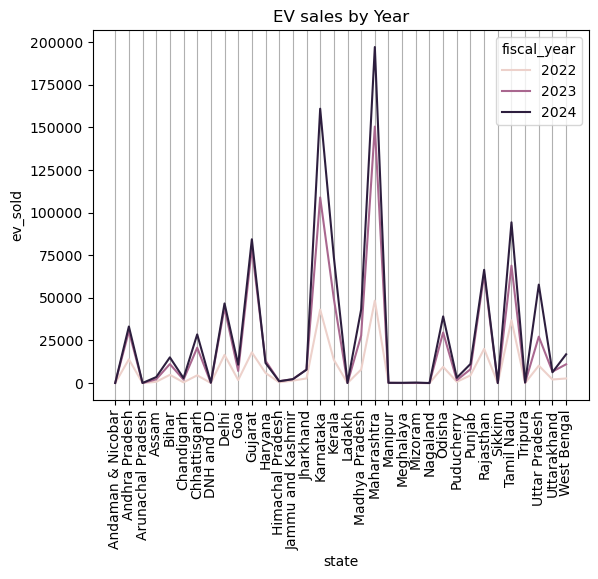

In [57]:
sns.lineplot(data=ev_per_state_fy, x='state', y='ev_sold', hue='fiscal_year')
plt.xticks(rotation=90)
plt.title('EV sales by Year')
plt.grid(axis='x')
plt.show()

In [58]:
ev_per_state_quarter = state_date.groupby(['quarter','state'])[['total_vehicles_sold','ev_sold']].sum()
ev_per_state_quarter.sort_values(by='ev_sold', ascending=False).reset_index().head(10)

,quarter,state,total_vehicles_sold,ev_sold
0,Q4,Maharashtra,1637064,132924
1,Q3,Maharashtra,1875616,113279
2,Q4,Karnataka,1098074,104711
3,Q3,Karnataka,1071644,79666
4,Q2,Maharashtra,1435130,76596
5,Q1,Maharashtra,1153619,73246
6,Q4,Tamil Nadu,1349225,70092
7,Q2,Karnataka,1010508,66098
8,Q1,Karnataka,814103,62520
9,Q4,Gujarat,967442,51874
